<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/symmetric_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


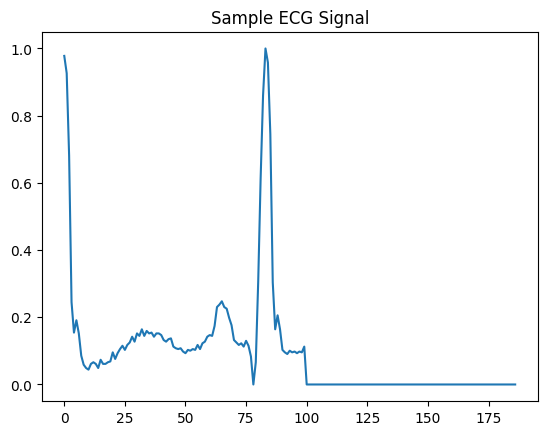

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

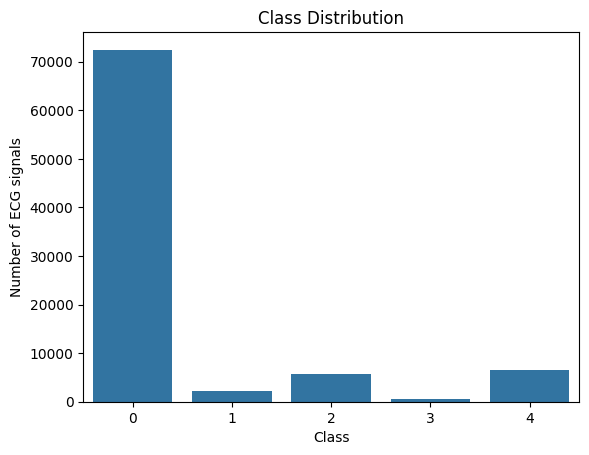

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def symmetric_cross_entropy(alpha=1.0, beta=1.0):

    def loss(y_true, y_pred):

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        rce = -tf.reduce_sum(y_pred * tf.math.log(y_true + 1e-7), axis=-1)

        return alpha * ce + beta * rce

    return loss

In [13]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=symmetric_cross_entropy(alpha=1.0, beta=1.0),
        metrics=['accuracy']
    )

    return model

In [14]:
from sklearn.model_selection import KFold
import tensorflow.keras.backend as K
import gc

kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    history = model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=1)

    print("Validation Accuracy:", acc)

    cv_accuracies.append(acc)

    # Clear memory after each fold
    K.clear_session()
    gc.collect()

print("\nCV accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 340s 89ms/step - accuracy: 0.8942 - loss: 2.4034
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 340s 90ms/step - accuracy: 0.9689 - loss: 0.7005
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 332s 88ms/step - accuracy: 0.9792 - loss: 0.4737
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 335s 89ms/step - accuracy: 0.9841 - loss: 0.3666
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 380s 88ms/step - accuracy: 0.9861 - loss: 0.3152
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.9560 - loss: 0.9742
Validation Accuracy: 0.9766527414321899

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 337s 88ms/step - accuracy: 0.8834 - loss: 2.5850
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 329s 87ms/step - accuracy: 0.9664 - loss: 0.7598
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 329s 87ms/step - accuracy: 0.9778 - loss: 0.5050
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 327s 86ms/step - accuracy: 0.9819 - loss: 0.4089
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 327s 87ms/step

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [17]:
model = mobilenet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 431s 92ms/step - accuracy: 0.8901 - loss: 2.4404 - val_accuracy: 0.9658 - val_loss: 0.7754
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 417s 92ms/step - accuracy: 0.9716 - loss: 0.6462 - val_accuracy: 0.9270 - val_loss: 1.5544
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 422s 93ms/step - accuracy: 0.9809 - loss: 0.4356 - val_accuracy: 0.9814 - val_loss: 0.4185
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 419s 93ms/step - accuracy: 0.9853 - loss: 0.3384 - val_accuracy: 0.9707 - val_loss: 0.6326
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 422s 93ms/step - accuracy: 0.9871 - loss: 0.2934 - val_accuracy: 0.8742 - val_loss: 2.6047
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 424s 94ms/step - accuracy: 0.9893 - loss: 0.2430 - val_accuracy: 0.8874 - val_loss: 2.6751
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 423s 93ms/step - accuracy: 0.9905 - loss: 0.2162 - val_accuracy: 0.9830 - val_loss: 0.3645
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 420s 93ms/step - accuracy: 

In [18]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax((y_val+1)/2, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)


2265/2265 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step
Validation MCC: 0.7375990854826792


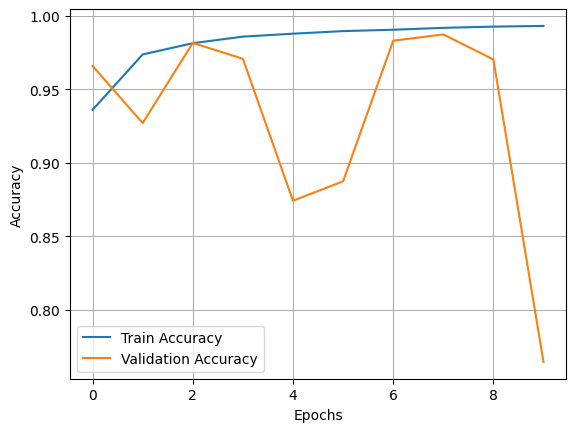

Final Training Accuracy: 0.9930
Final Validation Accuracy: 0.7646


In [19]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Final training & validation loss and accuracy

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]


print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

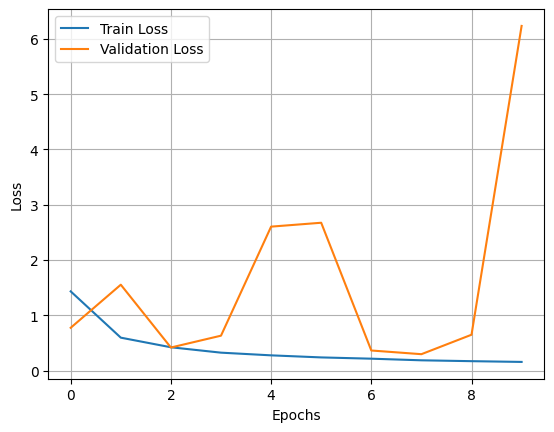

Final Training Loss: 0.1579
Final Validation Loss: 6.2348


In [20]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [22]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.9666
Test Accuracy: 0.9583
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98     72471
         1.0       0.52      0.71      0.60      2223
         2.0       0.98      0.88      0.93      5788
         3.0       0.80      0.01      0.02       641
         4.0       0.97      0.99      0.98      6431

    accuracy                           0.96     87554
   macro avg       0.85      0.71      0.70     87554
weighted avg       0.96      0.96      0.96     87554



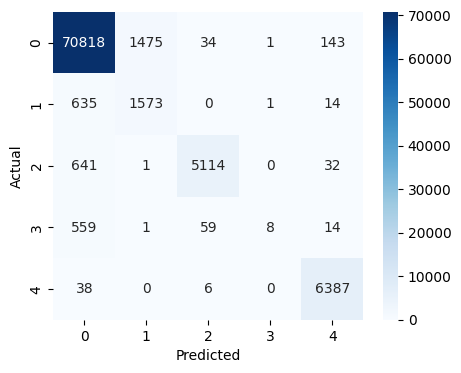

In [23]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()